Dashboard saved to: /Users/anirudhsoni/AML Dashboard/fraud_intelligence_dashboard.png
Transactions: 1,000
Accounts: 1,000
Alerts: 1,000
Fraud rate: 0.20%
Flagged accounts: 78


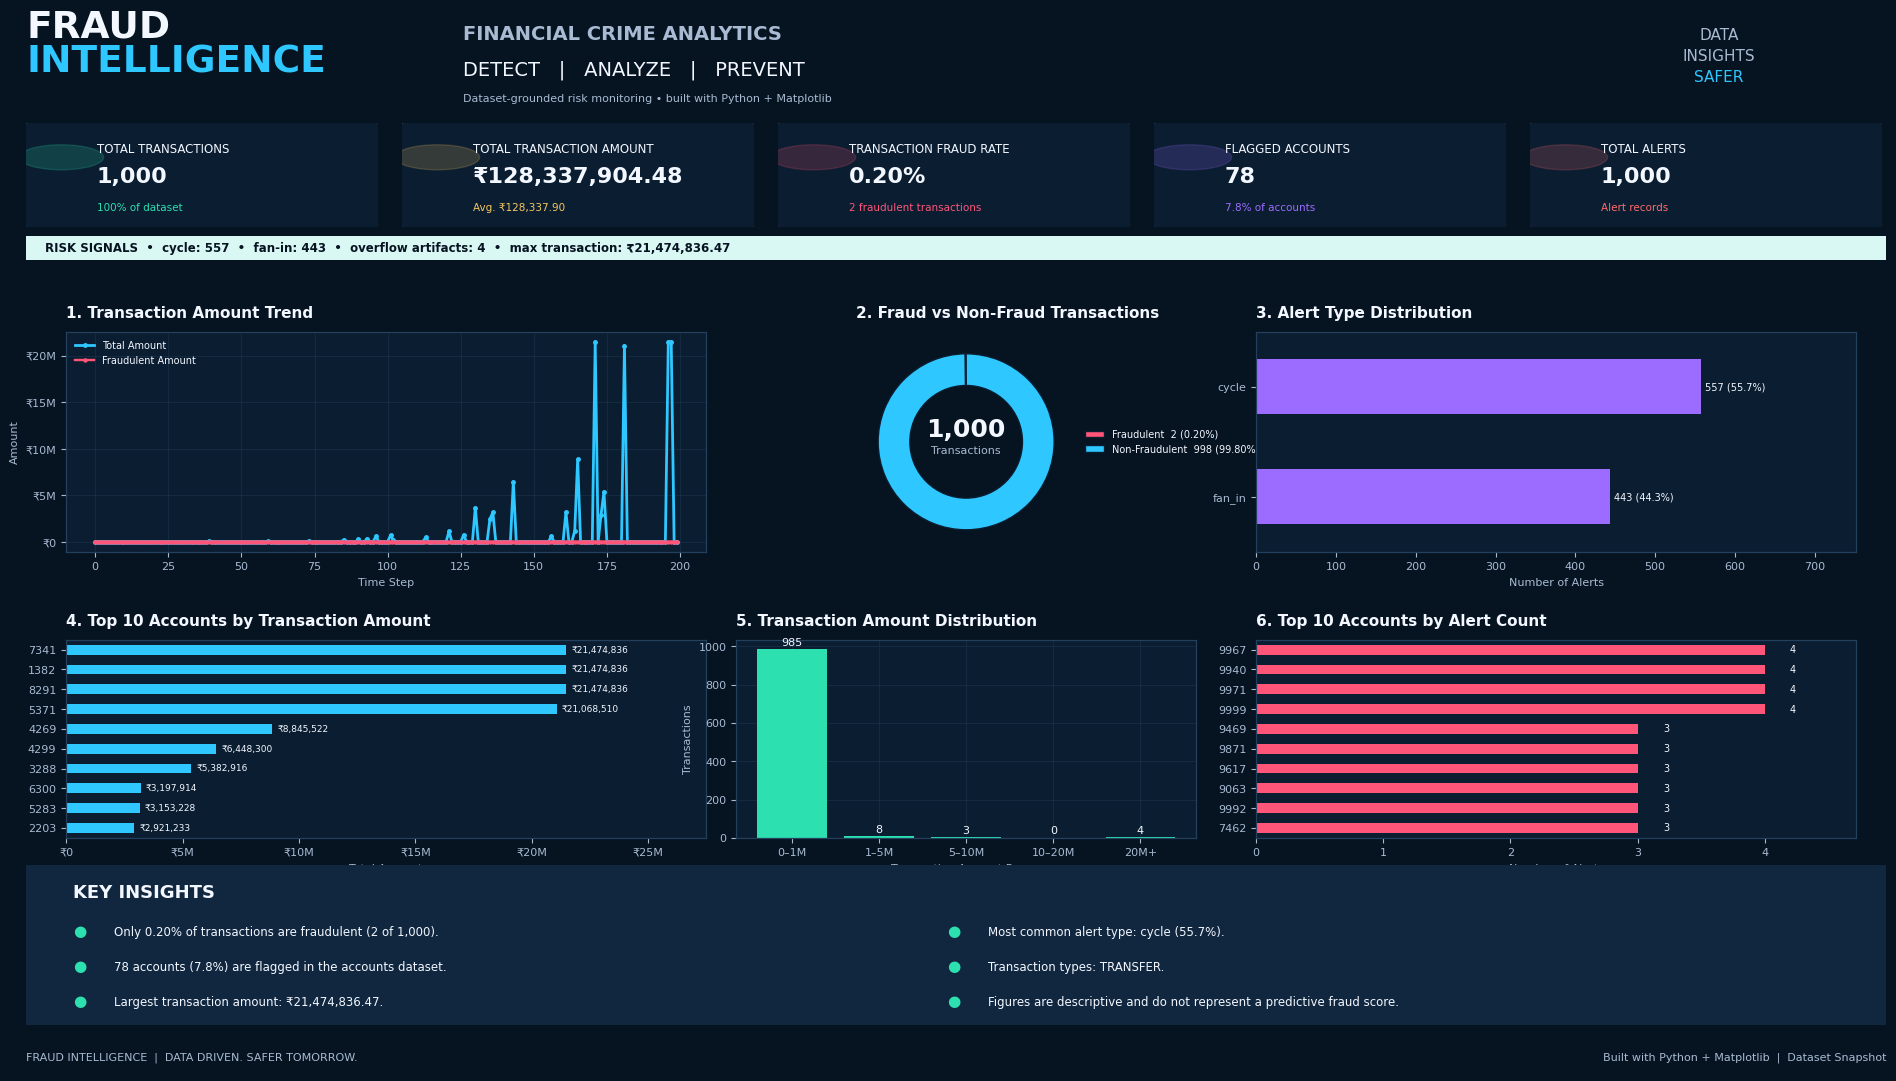

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.ticker import FuncFormatter

# ============================================================
# 1. FILE PATHS — keep CSVs in the same folder as this script
# ============================================================
BASE_DIR = os.getcwd()
TX_FILE = os.path.join(BASE_DIR, "transactions_dashboard_ready.csv")
ACCOUNTS_FILE = os.path.join(BASE_DIR, "accounts_cleaned.csv")
ALERTS_FILE = os.path.join(BASE_DIR, "alerts_cleaned.csv")
OUTPUT_FILE = os.path.join(BASE_DIR, "fraud_intelligence_dashboard.png")

# ============================================================
# 2. THEME
# ============================================================
BG = "#061321"
PANEL = "#0B1D31"
PANEL_2 = "#10273F"
GRID = "#23415D"
TEXT = "#F3F7FF"
MUTED = "#A8BBD2"
CYAN = "#2EC7FF"
TEAL = "#2DE0B0"
PURPLE = "#9B6CFF"
PINK = "#FF5578"
YELLOW = "#F6C85F"
CORAL = "#FF6B6B"
GREEN = "#46E0A0"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"

# ============================================================
# 3. LOAD AND VALIDATE YOUR DATA
# ============================================================
for path in [TX_FILE, ACCOUNTS_FILE, ALERTS_FILE]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing file: {path}\n"
            "Place the three CSV files in the same folder as this script."
        )

transactions = pd.read_csv(TX_FILE)
accounts = pd.read_csv(ACCOUNTS_FILE)
alerts = pd.read_csv(ALERTS_FILE)

required_tx = {
    "tx_id", "sender_account_id", "tx_amount", "tx_time_step", "is_fraud"
}
required_accounts = {"account_id", "is_fraud"}
required_alerts = {"alert_type"}

missing_tx = required_tx - set(transactions.columns)
missing_accounts = required_accounts - set(accounts.columns)
missing_alerts = required_alerts - set(alerts.columns)

if missing_tx or missing_accounts or missing_alerts:
    raise ValueError(
        f"Missing columns -> transactions: {missing_tx}; "
        f"accounts: {missing_accounts}; alerts: {missing_alerts}"
    )

if transactions.empty:
    raise ValueError("Transactions dataset is empty.")

transactions["tx_amount"] = pd.to_numeric(transactions["tx_amount"], errors="coerce")
transactions["tx_time_step"] = pd.to_numeric(transactions["tx_time_step"], errors="coerce")
transactions["is_fraud"] = pd.to_numeric(transactions["is_fraud"], errors="coerce").fillna(0).astype(int)
accounts["is_fraud"] = pd.to_numeric(accounts["is_fraud"], errors="coerce").fillna(0).astype(int)

if transactions[["tx_amount", "tx_time_step"]].isna().any().any():
    raise ValueError("tx_amount or tx_time_step contains invalid/missing values.")

# ============================================================
# 4. METRICS — calculated directly from the supplied datasets
# ============================================================
N_TX = len(transactions)
N_ACCOUNTS = len(accounts)
N_ALERTS = len(alerts)
TOTAL_AMOUNT = transactions["tx_amount"].sum()
FRAUD_TX = int(transactions["is_fraud"].sum())
NON_FRAUD_TX = N_TX - FRAUD_TX
FRAUD_RATE = FRAUD_TX / N_TX * 100 if N_TX else 0
FLAGGED_ACCOUNTS = int(accounts["is_fraud"].sum())
ACCOUNT_FLAG_RATE = FLAGGED_ACCOUNTS / N_ACCOUNTS * 100 if N_ACCOUNTS else 0
MAX_AMOUNT = transactions["tx_amount"].max()

# ============================================================
# 5. ANALYTICAL TABLES FOR SIX CHARTS
# ============================================================
# Chart 1: amount trend by time step
trend = (
    transactions.sort_values("tx_time_step")
    .groupby("tx_time_step", as_index=False)
    .agg(
        total_amount=("tx_amount", "sum"),
        fraudulent_amount=("tx_amount", lambda s: s[transactions.loc[s.index, "is_fraud"].eq(1)].sum()),
    )
)

# Chart 2: fraud versus non-fraud
fraud_values = [FRAUD_TX, NON_FRAUD_TX]

# Chart 3: alert type distribution
alert_counts = alerts["alert_type"].fillna("unknown").value_counts()

# Chart 4: top 10 accounts by outgoing transaction amount
top_amount_accounts = (
    transactions.groupby("sender_account_id", as_index=True)["tx_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

# Chart 5: amount distribution
bins = [0, 1_000_000, 5_000_000, 10_000_000, 20_000_000, np.inf]
bin_labels = ["0–1M", "1–5M", "5–10M", "10–20M", "20M+"]
amount_buckets = pd.cut(
    transactions["tx_amount"], bins=bins, labels=bin_labels, right=False
)
amount_distribution = amount_buckets.value_counts().reindex(bin_labels, fill_value=0)

# Chart 6: top 10 accounts by alert count.
# The supplied alerts file contains sender_account_id, so use it.
if "sender_account_id" in alerts.columns:
    alert_account_col = "sender_account_id"
elif "account_id" in alerts.columns:
    alert_account_col = "account_id"
else:
    alert_account_col = None

if alert_account_col:
    top_alert_accounts = (
        alerts[alert_account_col].fillna("Unknown").value_counts()
        .head(10).sort_values()
    )
else:
    top_alert_accounts = pd.Series(dtype="int64")

# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================
def money(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"₹{x / 1_000_000:.0f}M"
    if abs(x) >= 1_000:
        return f"₹{x / 1_000:.0f}K"
    return f"₹{x:.0f}"


def style_axis(ax):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.grid(True, color=GRID, alpha=0.45, linewidth=0.6)
    ax.set_axisbelow(True)


def panel_title(ax, title):
    ax.set_title(title, loc="left", color=TEXT, fontsize=11, pad=10, fontweight="bold")


def add_kpi(fig, x, y, w, h, title, value, subtitle, accent):
    ax = fig.add_axes([x, y, w, h])
    ax.set_axis_off()
    ax.add_patch(
        FancyBboxPatch(
            (0, 0), 1, 1,
            boxstyle="round,pad=0.012,rounding_size=0.04",
            facecolor=PANEL,
            edgecolor=accent,
            linewidth=1.1,
            transform=ax.transAxes,
        )
    )
    ax.add_patch(Circle((0.10, 0.67), 0.12, color=accent, alpha=0.18, transform=ax.transAxes))
    ax.text(0.20, 0.72, title, color=TEXT, fontsize=8.5, transform=ax.transAxes)
    ax.text(0.20, 0.43, value, color=TEXT, fontsize=16, fontweight="bold", transform=ax.transAxes)
    ax.text(0.20, 0.16, subtitle, color=accent, fontsize=7.5, transform=ax.transAxes)
    return ax


def panel_box(fig, x, y, w, h):
    ax = fig.add_axes([x, y, w, h])
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
        spine.set_linewidth(0.9)
    return ax

# ============================================================
# 7. BUILD THE DASHBOARD CANVAS
# ============================================================
fig = plt.figure(figsize=(20, 11), facecolor=BG)
fig.subplots_adjust(0, 0, 1, 1)

# Header
header = fig.add_axes([0.035, 0.905, 0.93, 0.075])
header.set_axis_off()
header.text(0.00, 0.70, "FRAUD", color=TEXT, fontsize=27, fontweight="bold")
header.text(0.00, 0.28, "INTELLIGENCE", color=CYAN, fontsize=27, fontweight="bold")
header.text(0.235, 0.67, "FINANCIAL CRIME ANALYTICS", color=MUTED, fontsize=14, fontweight="bold")
header.text(0.235, 0.25, "DETECT   |   ANALYZE   |   PREVENT", color=TEXT, fontsize=14)
header.text(0.235, -0.08, "Dataset-grounded risk monitoring • built with Python + Matplotlib", color=MUTED, fontsize=8)
header.text(0.91, 0.67, "DATA", color=MUTED, fontsize=11, ha="center")
header.text(0.91, 0.42, "INSIGHTS", color=MUTED, fontsize=11, ha="center")
header.text(0.91, 0.17, "SAFER", color=CYAN, fontsize=11, ha="center")

# KPI cards
kpi_y, kpi_h, kpi_w, kpi_gap = 0.785, 0.095, 0.176, 0.012
kpi_xs = [0.035 + i * (kpi_w + kpi_gap) for i in range(5)]
add_kpi(fig, kpi_xs[0], kpi_y, kpi_w, kpi_h, "TOTAL TRANSACTIONS", f"{N_TX:,}", "100% of dataset", TEAL)
add_kpi(fig, kpi_xs[1], kpi_y, kpi_w, kpi_h, "TOTAL TRANSACTION AMOUNT", f"₹{TOTAL_AMOUNT:,.2f}", f"Avg. ₹{TOTAL_AMOUNT / N_TX:,.2f}", YELLOW)
add_kpi(fig, kpi_xs[2], kpi_y, kpi_w, kpi_h, "TRANSACTION FRAUD RATE", f"{FRAUD_RATE:.2f}%", f"{FRAUD_TX} fraudulent transactions", PINK)
add_kpi(fig, kpi_xs[3], kpi_y, kpi_w, kpi_h, "FLAGGED ACCOUNTS", f"{FLAGGED_ACCOUNTS:,}", f"{ACCOUNT_FLAG_RATE:.1f}% of accounts", PURPLE)
add_kpi(fig, kpi_xs[4], kpi_y, kpi_w, kpi_h, "TOTAL ALERTS", f"{N_ALERTS:,}", "Alert records", CORAL)

# Risk strip
strip = fig.add_axes([0.035, 0.755, 0.93, 0.022])
strip.set_axis_off()
strip.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.01,rounding_size=0.02", facecolor="#D9F7F3", edgecolor="none"))
cycle_count = int((alerts["alert_type"] == "cycle").sum())
fan_in_count = int((alerts["alert_type"] == "fan_in").sum())
overflow_count = int((transactions.get("amount_anomaly_flag", pd.Series(dtype=str)) == "Overflow Artifact").sum())
strip.text(0.01, 0.5, f"RISK SIGNALS  •  cycle: {cycle_count}  •  fan-in: {fan_in_count}  •  overflow artifacts: {overflow_count}  •  max transaction: ₹{MAX_AMOUNT:,.2f}", va="center", color=BG, fontsize=8.5, fontweight="bold")

# Chart layout: 3 panels top, 3 panels bottom
positions = [
    (0.035, 0.485, 0.32, 0.245),
    (0.365, 0.485, 0.29, 0.245),
    (0.665, 0.485, 0.30, 0.245),
    (0.035, 0.245, 0.32, 0.215),
    (0.365, 0.245, 0.29, 0.215),
    (0.665, 0.245, 0.30, 0.215),
]

# Chart 1
ax1 = panel_box(fig, *positions[0])
style_axis(ax1)
panel_title(ax1, "1. Transaction Amount Trend")
ax1.plot(trend["tx_time_step"], trend["total_amount"], color=CYAN, linewidth=2.0, marker="o", markersize=2.5, label="Total Amount")
ax1.plot(trend["tx_time_step"], trend["fraudulent_amount"], color=PINK, linewidth=1.7, marker="o", markersize=2.2, label="Fraudulent Amount")
ax1.yaxis.set_major_formatter(FuncFormatter(money))
ax1.set_xlabel("Time Step", fontsize=8)
ax1.set_ylabel("Amount", fontsize=8)
ax1.legend(loc="upper left", fontsize=7, frameon=False, labelcolor=TEXT)

# Chart 2
ax2 = panel_box(fig, *positions[1])
style_axis(ax2)
panel_title(ax2, "2. Fraud vs Non-Fraud Transactions")
wedges, _ = ax2.pie(fraud_values, startangle=90, colors=[PINK, CYAN], wedgeprops=dict(width=0.36, edgecolor=PANEL))
ax2.text(0, 0.06, f"{N_TX:,}", ha="center", color=TEXT, fontsize=18, fontweight="bold")
ax2.text(0, -0.13, "Transactions", ha="center", color=MUTED, fontsize=8)
ax2.legend([f"Fraudulent  {FRAUD_TX} ({FRAUD_RATE:.2f}%)", f"Non-Fraudulent  {NON_FRAUD_TX} ({100-FRAUD_RATE:.2f}%)"], loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=7, labelcolor=TEXT)
ax2.set_aspect("equal")

# Chart 3
ax3 = panel_box(fig, *positions[2])
style_axis(ax3)
panel_title(ax3, "3. Alert Type Distribution")
alert_counts.sort_values().plot(kind="barh", ax=ax3, color=PURPLE, edgecolor="none")
ax3.set_xlabel("Number of Alerts", fontsize=8)
ax3.set_ylabel("")
for i, value in enumerate(alert_counts.sort_values().values):
    ax3.text(value + max(alert_counts.max() * 0.01, 1), i, f"{value} ({value / N_ALERTS * 100:.1f}%)", va="center", color=TEXT, fontsize=7)
ax3.set_xlim(0, max(alert_counts.max() * 1.35, 1))

# Chart 4
ax4 = panel_box(fig, *positions[3])
style_axis(ax4)
panel_title(ax4, "4. Top 10 Accounts by Transaction Amount")
top_amount_accounts.plot(kind="barh", ax=ax4, color=CYAN, edgecolor="none")
ax4.xaxis.set_major_formatter(FuncFormatter(money))
ax4.set_xlabel("Total Amount", fontsize=8)
ax4.set_ylabel("")
for i, value in enumerate(top_amount_accounts.values):
    ax4.text(value + max(top_amount_accounts.max() * 0.01, 1), i, f"₹{value:,.0f}", va="center", color=TEXT, fontsize=6.5)
ax4.set_xlim(0, top_amount_accounts.max() * 1.28)

# Chart 5
ax5 = panel_box(fig, *positions[4])
style_axis(ax5)
ax5.set_title("5. Transaction Amount Distribution", loc="left", color=TEXT, fontsize=11, pad=10, fontweight="bold")
bars = ax5.bar(amount_distribution.index, amount_distribution.values, color=TEAL, edgecolor="none")
ax5.set_xlabel("Transaction Amount Range", fontsize=8)
ax5.set_ylabel("Transactions", fontsize=8)
ax5.tick_params(axis="x", rotation=0)
for bar, value in zip(bars, amount_distribution.values):
    ax5.text(bar.get_x() + bar.get_width() / 2, value + max(amount_distribution.max() * 0.02, 1), str(int(value)), ha="center", color=TEXT, fontsize=8)

# Chart 6
ax6 = panel_box(fig, *positions[5])
style_axis(ax6)
panel_title(ax6, "6. Top 10 Accounts by Alert Count")
if not top_alert_accounts.empty:
    top_alert_accounts.plot(kind="barh", ax=ax6, color=PINK, edgecolor="none")
    ax6.set_xlabel("Number of Alerts", fontsize=8)
    ax6.set_ylabel("")
    for i, value in enumerate(top_alert_accounts.values):
        ax6.text(value + 0.2, i, str(int(value)), va="center", color=TEXT, fontsize=7)
    ax6.set_xlim(0, top_alert_accounts.max() * 1.18)
else:
    ax6.text(0.5, 0.5, "No account identifier available in alerts file", ha="center", va="center", color=MUTED)
    ax6.set_xticks([]); ax6.set_yticks([])

# Bottom insight panel
insight = fig.add_axes([0.035, 0.06, 0.93, 0.145])
insight.set_axis_off()
insight.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.012,rounding_size=0.025", facecolor=PANEL_2, edgecolor=GRID, linewidth=1))
insight.text(0.025, 0.80, "KEY INSIGHTS", color=TEXT, fontsize=13, fontweight="bold")
insights = [
    f"Only {FRAUD_RATE:.2f}% of transactions are fraudulent ({FRAUD_TX:,} of {N_TX:,}).",
    f"{FLAGGED_ACCOUNTS:,} accounts ({ACCOUNT_FLAG_RATE:.1f}%) are flagged in the accounts dataset.",
    f"Largest transaction amount: ₹{MAX_AMOUNT:,.2f}.",
    f"Most common alert type: {alert_counts.index[0]} ({alert_counts.iloc[0] / N_ALERTS * 100:.1f}%).",
    f"Transaction types: {', '.join(map(str, transactions['tx_type'].dropna().unique())) if 'tx_type' in transactions.columns else 'Not available'}.",
    "Figures are descriptive and do not represent a predictive fraud score.",
]
for i, text in enumerate(insights):
    col = 0 if i < 3 else 1
    row = i if i < 3 else i - 3
    x = 0.025 + col * 0.47
    y = 0.56 - row * 0.22
    insight.text(x, y, "●", color=TEAL, fontsize=11)
    insight.text(x + 0.022, y, text, color=TEXT, fontsize=8.5)

# Footer
footer = fig.add_axes([0.035, 0.018, 0.93, 0.025])
footer.set_axis_off()
footer.text(0, 0.5, "FRAUD INTELLIGENCE  |  DATA DRIVEN. SAFER TOMORROW.", color=MUTED, fontsize=8, va="center")
footer.text(1, 0.5, "Built with Python + Matplotlib  |  Dataset Snapshot", color=MUTED, fontsize=8, va="center", ha="right")

# SECOND ROW — MOVE DOWN

ax4.set_position([0.055, 0.23, 0.32, 0.18])

ax5.set_position([0.39, 0.23, 0.23, 0.18])

ax6.set_position([0.65, 0.23, 0.30, 0.18])

# FIRST ROW

ax1.set_position([0.055, 0.49, 0.32, 0.20])

ax2.set_position([0.39, 0.49, 0.23, 0.20])

ax3.set_position([0.65, 0.49, 0.30, 0.20])

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:

    ax.title.set_fontsize(12)

    ax.title.set_fontweight("bold")

    ax.title.set_position((0.5, 1.08))
    
# Save and show
fig.savefig(OUTPUT_FILE, dpi=220, facecolor=BG, bbox_inches="tight")
print(f"Dashboard saved to: {OUTPUT_FILE}")
print(f"Transactions: {N_TX:,}")
print(f"Accounts: {N_ACCOUNTS:,}")
print(f"Alerts: {N_ALERTS:,}")
print(f"Fraud rate: {FRAUD_RATE:.2f}%")
print(f"Flagged accounts: {FLAGGED_ACCOUNTS:,}")
plt.show()


In [2]:
OUTPUT_FILE = "/Users/anirudhsoni/AML Dashboard/fraud_intelligence_dashboard.png"

fig.savefig(
    OUTPUT_FILE,
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

print(f"Dashboard saved to: {OUTPUT_FILE}")

plt.show()

Dashboard saved to: /Users/anirudhsoni/AML Dashboard/fraud_intelligence_dashboard.png
